# III: Reduction and Background
# Notebook with some basic data reduction and analysis with python

## First, import necessary libraries

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits

## Let's open fits files

In [ ]:
dir = '/content/sample_data/' # directory where fits files are found
file1= dir+'FORS2.2004-04-13T08_46_13.580.fits' #file names
science = fits.getdata(file1)  # data matrices
file2= dir+'master_bias.fits' #file names
master_bias = fits.getdata(file2)  # data matrices
file3= dir+'master_flat.fits' #file names
master_flat = fits.getdata(file3)  # data matrices

## Reduce the science file

In [ ]:
science_calibrated=(science-master_bias)/master_flat
#This example needs a mask!
mask=np.zeros(np.shape(science_calibrated))
for i in range(len(science_calibrated)):
  for j in range(len(science_calibrated[i])):
    if master_flat[i][j]<0.2:
      science_calibrated[i][j]=0
      mask[i][j]=1
mask=mask.astype(bool)

<ipython-input-41-cc0ce08ede31>:1: RuntimeWarning: divide by zero encountered in divide
  science_calibrated=(science-master_bias)/master_flat
<ipython-input-41-cc0ce08ede31>:1: RuntimeWarning: invalid value encountered in divide
  science_calibrated=(science-master_bias)/master_flat


1610108


## Plot fits files

Text(0, 0.5, 'ypix')

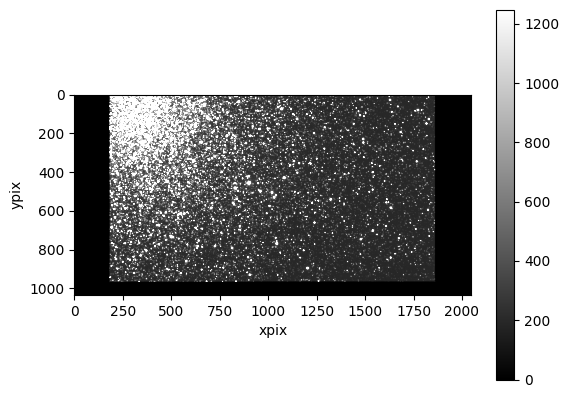

In [ ]:
#one plot
lo,up = np.percentile(science_calibrated,5),np.percentile(science_calibrated,95)
plt.figure()
plt.imshow(science_calibrated,cmap='gray',clim=(lo,up))
plt.colorbar()
plt.xlabel('xpix')
plt.ylabel('ypix')

## Get background and background noise

In [ ]:
!pip install photutils #only needed if its being run on colabs

In [ ]:
from photutils import Background2D,MedianBackground
from astropy.stats import SigmaClip
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg = Background2D(science_calibrated,(50,50),filter_size=(3,3),sigma_clip=sigma_clip, bkg_estimator=bkg_estimator,coverage_mask=mask)
print("      Median background found: %f, median bkg noise: %f"
      %(bkg.background_median,bkg.background_rms_median)  )

<ipython-input-38-ba4401a7571d>:1: DeprecationWarning: `photutils.Background2D` is a deprecated alias for `photutils.background.Background2D` and will be removed in the future. Instead, please use `from photutils.background import Background2D` to silence this warning.
  from photutils import Background2D,MedianBackground
<ipython-input-38-ba4401a7571d>:1: DeprecationWarning: `photutils.MedianBackground` is a deprecated alias for `photutils.background.MedianBackground` and will be removed in the future. Instead, please use `from photutils.background import MedianBackground` to silence this warning.
  from photutils import Background2D,MedianBackground


      Median background found: 199.875543, median bkg noise: 16.655309


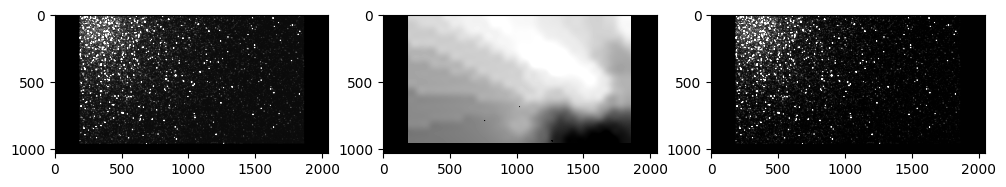

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(12,6))
lo,up = np.percentile(science_calibrated,1),np.percentile(science_calibrated,99)
ax[0].imshow(science_calibrated,cmap='gray',clim=(lo,up))
lo,up = np.percentile(bkg.background[mask==False],1),np.percentile(bkg.background[mask==False],95)
ax[1].imshow(bkg.background,cmap='gray',clim=(lo,up))
lo,up = np.percentile(science_calibrated-bkg.background,1),np.percentile(science_calibrated-bkg.background,99)
ax[2].imshow(science_calibrated-bkg.background,cmap='gray',clim=(lo,up))

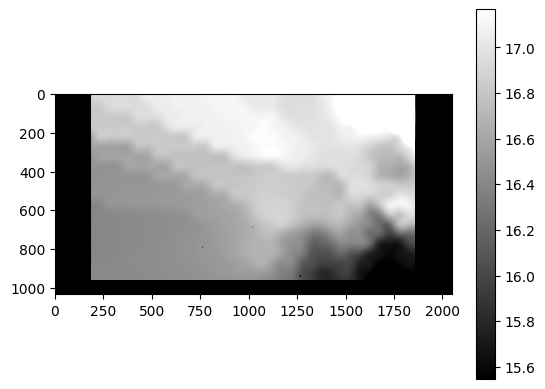

In [ ]:
lo,up = np.percentile(bkg.background_rms[mask==False],1),np.percentile(bkg.background_rms[mask==False],95)
plt.imshow(bkg.background_rms,cmap='gray',clim=(lo,up))
plt.colorbar()